# Aprendizaje por refuerzo muy dummy en Google Colab

Este cuaderno está pensado para **entender la idea de reinforcement learning (RL)** sin entrar de una vez en redes neuronales complejas.

Usaremos **Q-learning**, una técnica clásica y sencilla, con un juego de tipo discreto como:

- `FrozenLake-v1`
- `Taxi-v3`
- `CliffWalking-v0`

La meta es que puedas:

1. Entender qué es un **agente**, un **entorno**, un **estado**, una **acción** y una **recompensa**.
2. Ver cómo el agente **aprende por ensayo y error**.
3. Cambiar de juego con una sola variable.
4. Tener una base intuitiva antes de pasar a métodos más avanzados como DQN.

---

## Analogía general

Imagina que entrenas a un perro en una casa nueva:

- El **entorno** es la casa.
- El **agente** es el perro.
- El **estado** es dónde está y qué ve.
- La **acción** es moverse, girar, avanzar, etc.
- La **recompensa** es un premio o una corrección.
- La **política** es la costumbre que el perro aprende: *"si estoy aquí, hago esto"*.

En RL no le damos la respuesta exacta.  
Solo le decimos, en esencia: **"prueba, observa qué pasó, y ajusta tu estrategia"**.

In [1]:
# Instalación para Google Colab
!pip -q install gymnasium[toy-text] matplotlib numpy

## 1) Importaciones

Usaremos:

- `gymnasium` para los entornos de juego.
- `numpy` para la tabla Q.
- `matplotlib` para visualizar el aprendizaje.

La **tabla Q** será como un cuaderno donde el agente anota:

> "Si estoy en este estado y hago esta acción, ¿qué tan buena idea fue?"

Al principio ese cuaderno está vacío.  
Luego se va llenando con experiencia.

In [2]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

## 2) Elegir el juego

Aquí puedes cambiar el entorno sin tocar el resto del cuaderno.

### Recomendación
- Empieza con **`FrozenLake-v1`** si quieres algo muy visual e intuitivo.
- Usa **`Taxi-v3`** si quieres un entorno un poco más estructurado.
- Usa **`CliffWalking-v0`** si quieres ver claramente castigos fuertes por malas decisiones.

### Importante
Este cuaderno está hecho para **entornos discretos**, es decir:

- número finito de estados,
- número finito de acciones.

Por eso **CartPole** no entra directamente en este ejemplo base, porque su espacio de estados es continuo.

In [16]:
# =========================
# CONFIGURACIÓN DEL JUEGO
# =========================

ENV_NAME = "Taxi-v3"   # Cambia por: "Taxi-v3" o "CliffWalking-v0"

# Parámetros opcionales según entorno
ENV_KWARGS = {}

# Para FrozenLake:
# is_slippery=True introduce azar y lo hace más difícil
if ENV_NAME == "FrozenLake-v1":
    ENV_KWARGS = {"is_slippery": False}

## 3) Crear el entorno y revisar sus dimensiones

Aquí inspeccionamos:

- cuántos **estados** existen,
- cuántas **acciones** puede tomar el agente.

### Analogía
Si el entorno fuera un edificio:

- los **estados** serían las habitaciones posibles,
- las **acciones** serían las puertas o movimientos disponibles.

La tabla Q entonces tendría forma:

**(número de estados) x (número de acciones)**

porque para cada estado queremos valorar cada acción posible.

In [17]:
env = gym.make(ENV_NAME, **ENV_KWARGS)

# Verificamos que el entorno sea discreto
assert hasattr(env.observation_space, "n"), "Este cuaderno base requiere estados discretos."
assert hasattr(env.action_space, "n"), "Este cuaderno base requiere acciones discretas."

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Entorno:", ENV_NAME)
print("Número de estados:", n_states)
print("Número de acciones:", n_actions)
print("Espacio de observación:", env.observation_space)
print("Espacio de acción:", env.action_space)

Entorno: Taxi-v3
Número de estados: 500
Número de acciones: 6
Espacio de observación: Discrete(500)
Espacio de acción: Discrete(6)


## 4) ¿Qué es la tabla Q?

La tabla Q guarda una puntuación estimada para cada par **(estado, acción)**.

\[
Q(s,a)
\]

se interpreta como:

> "Si estoy en el estado `s` y tomo la acción `a`, ¿qué tan prometedor parece eso a futuro?"

### Analogía
Imagina una libreta con consejos:

- "Si estás en esta esquina del laberinto y vas a la derecha, suele ir bien."
- "Si estás cerca del precipicio y avanzas, suele salir mal."

Al principio todas las celdas de la tabla valen 0 porque el agente aún no sabe nada.

In [18]:
Q = np.zeros((n_states, n_actions))
Q.shape
Q

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

## 5) Hiperparámetros del aprendizaje

Estos son los controles del comportamiento del agente.

### `alpha` - tasa de aprendizaje
Qué tanto confía en la experiencia nueva.

- alto: cambia rápido de opinión,
- bajo: aprende más despacio pero de forma más estable.

### `gamma` - factor de descuento
Qué tanto valora el futuro.

- cercano a 0: piensa casi solo en la recompensa inmediata,
- cercano a 1: piensa más estratégicamente.

### `epsilon` - exploración
Probabilidad de hacer algo aleatorio.

### Analogía
Un explorador puede:

- **explorar**: probar caminos nuevos,
- **explotar**: usar el mejor camino conocido.

Si explora demasiado, tarda en consolidar una estrategia.  
Si explora muy poco, puede quedarse con una estrategia mediocre.

In [19]:
# =========================
# HIPERPARÁMETROS
# =========================
alpha = 0.1              # learning rate
gamma = 0.95             # discount factor

epsilon = 1.0            # exploración inicial
epsilon_min = 0.05
epsilon_decay = 0.995

episodes = 2500
max_steps = 100

print({
    "alpha": alpha,
    "gamma": gamma,
    "epsilon": epsilon,
    "epsilon_min": epsilon_min,
    "epsilon_decay": epsilon_decay,
    "episodes": episodes,
    "max_steps": max_steps,
})

{'alpha': 0.1, 'gamma': 0.95, 'epsilon': 1.0, 'epsilon_min': 0.05, 'epsilon_decay': 0.995, 'episodes': 2500, 'max_steps': 100}


## 6) Estrategia epsilon-greedy

Esta es la regla que mezcla exploración y explotación.

- Con probabilidad `epsilon`: elige una acción aleatoria.
- Con probabilidad `1 - epsilon`: elige la mejor acción conocida según la tabla Q.

### Analogía
Es como aprender a moverse por una ciudad:

- a veces sigues la ruta que ya sabes,
- a veces tomas una calle nueva por si resulta mejor.

Eso evita que el agente se "case" demasiado pronto con una solución mala.

In [20]:
def choose_action(state, Q, epsilon, env):
    if np.random.rand() < epsilon:
        return env.action_space.sample()  # explorar
    return np.argmax(Q[state])            # explotar

## 7) Regla de actualización de Q-learning

Cuando el agente ejecuta una acción y observa el resultado, actualiza:

\[
Q(s,a) \leftarrow Q(s,a) + \alpha \Big(r + \gamma \max_{a'}Q(s',a') - Q(s,a)\Big)
\]

### Intuición de la fórmula

- `Q(s,a)` es lo que el agente creía antes.
- `r` es la recompensa obtenida.
- `max Q(s', a')` es la mejor expectativa futura desde el nuevo estado.
- La diferencia entre lo esperado y lo observado corrige la creencia previa.

### Analogía
Es como decir:

> "Yo pensaba que esta decisión valía 2 puntos,  
> pero después de ver el premio inmediato y el potencial futuro, parece que en realidad vale 4.  
> Entonces ajusto mi libreta un poco en esa dirección."

In [21]:
def train_q_learning(env_name, env_kwargs, episodes=2500, max_steps=100,
                     alpha=0.1, gamma=0.95,
                     epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995):

    env = gym.make(env_name, **env_kwargs)
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    rewards_history = []
    epsilon_history = []
    success_history = []

    for episode in range(episodes):
        state, info = env.reset()
        total_reward = 0
        done = False

        for step in range(max_steps):
            action = choose_action(state, Q, epsilon, env)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            best_next = np.max(Q[next_state])
            td_target = reward + gamma * best_next
            td_error = td_target - Q[state, action]
            Q[state, action] = Q[state, action] + alpha * td_error

            state = next_state
            total_reward += reward

            if done:
                break

        rewards_history.append(total_reward)
        success_history.append(1 if total_reward > 0 else 0)
        epsilon_history.append(epsilon)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    env.close()
    return Q, rewards_history, epsilon_history, success_history

## 8) Entrenamiento

Aquí el agente repite muchos episodios.

Un **episodio** es una partida completa o un intento completo.  
Por ejemplo, en un laberinto sería:

- empieza en la entrada,
- se mueve varias veces,
- llega a la meta o fracasa,
- termina el episodio.

Con muchos episodios, el agente va refinando su tabla Q.

In [22]:
Q, rewards_history, epsilon_history, success_history = train_q_learning(
    env_name=ENV_NAME,
    env_kwargs=ENV_KWARGS,
    episodes=episodes,
    max_steps=max_steps,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    epsilon_min=epsilon_min,
    epsilon_decay=epsilon_decay,
)

print("Entrenamiento terminado.")
print("Forma de Q:", Q.shape)

Entrenamiento terminado.
Forma de Q: (500, 6)


## 9) Visualizar cómo aprendió

Veremos:

1. recompensa por episodio,
2. promedio móvil de recompensa,
3. cómo disminuyó `epsilon`,
4. tasa de éxito aproximada.

### Qué deberías esperar

- Al inicio: mucho ruido, mucho azar.
- Después: mejor rendimiento y menos exploración.

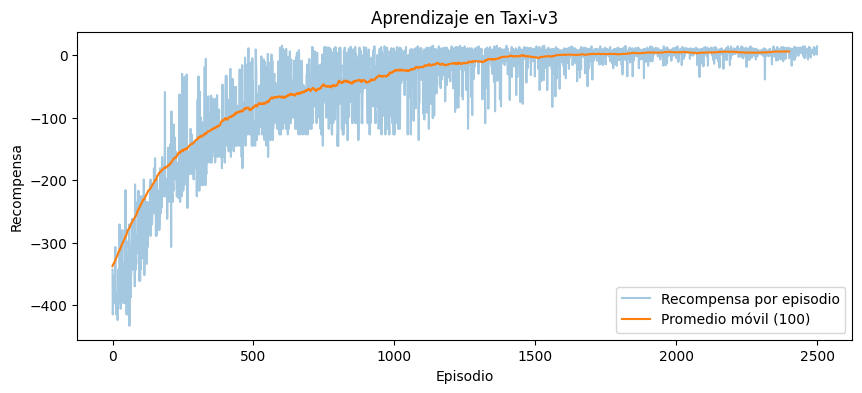

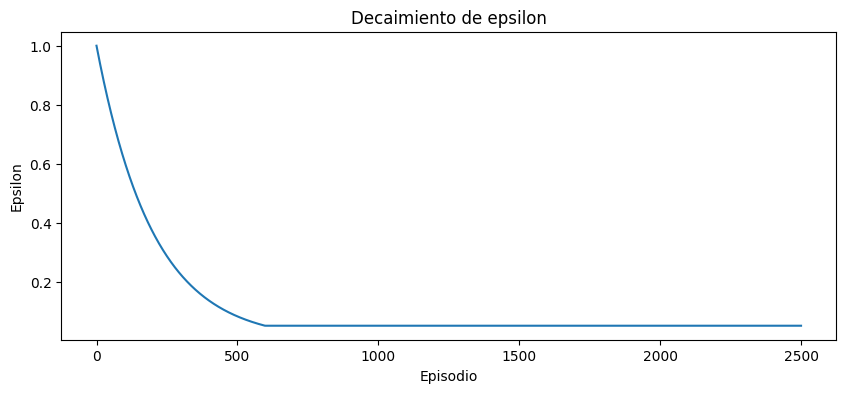

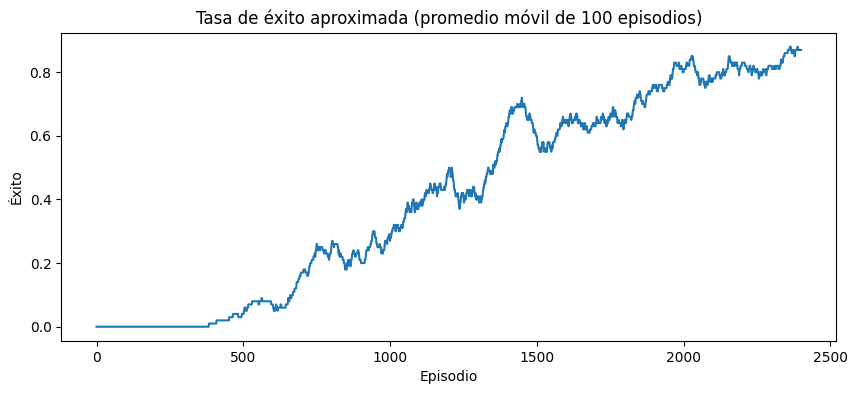

In [23]:
def moving_average(x, window=100):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

plt.figure(figsize=(10,4))
plt.plot(rewards_history, alpha=0.4, label="Recompensa por episodio")
ma = moving_average(rewards_history, window=100)
plt.plot(range(len(ma)), ma, label="Promedio móvil (100)")
plt.title(f"Aprendizaje en {ENV_NAME}")
plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(epsilon_history)
plt.title("Decaimiento de epsilon")
plt.xlabel("Episodio")
plt.ylabel("Epsilon")
plt.show()

plt.figure(figsize=(10,4))
success_ma = moving_average(success_history, window=100)
plt.plot(range(len(success_ma)), success_ma)
plt.title("Tasa de éxito aproximada (promedio móvil de 100 episodios)")
plt.xlabel("Episodio")
plt.ylabel("Éxito")
plt.show()

## 10) Política aprendida

La política final se obtiene tomando, en cada estado, la acción con mayor valor en Q:

\[
\pi(s) = rg\max_a Q(s,a)
\]

### Analogía
Es como convertir la libreta de experiencias en una guía definitiva:

> "Si estás aquí, la acción recomendada es esta."

No siempre será perfecta, pero representa lo mejor que el agente aprendió hasta ahora.

In [24]:
policy = np.argmax(Q, axis=1)
print("Primeros estados de la política aprendida:")
print(policy[:min(20, len(policy))])

Primeros estados de la política aprendida:
[0 4 4 4 2 0 0 2 0 0 0 0 1 0 2 0 5 0 0 0]


## 11) Evaluación sin explorar

Ahora el agente jugará **sin aleatoriedad**.  
Es decir, ya no está experimentando, solo usa lo que aprendió.

Esto es importante porque durante el entrenamiento el rendimiento puede verse afectado por la exploración.  
Para evaluar bien, normalmente ponemos `epsilon = 0`.

In [25]:
def evaluate_agent(env_name, env_kwargs, Q, episodes=20, max_steps=100):
    env = gym.make(env_name, **env_kwargs)
    rewards = []

    for _ in range(episodes):
        state, info = env.reset()
        total_reward = 0

        for _ in range(max_steps):
            action = np.argmax(Q[state])
            next_state, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        rewards.append(total_reward)

    env.close()
    return rewards

eval_rewards = evaluate_agent(ENV_NAME, ENV_KWARGS, Q, episodes=50, max_steps=max_steps)
print("Recompensa promedio en evaluación:", np.mean(eval_rewards))
print("Tasa de episodios exitosos:", np.mean(np.array(eval_rewards) > 0))

Recompensa promedio en evaluación: -0.62
Tasa de episodios exitosos: 0.92


## 12) Ver una partida renderizada

Esta parte intenta mostrar una partida del agente ya entrenado.

Dependiendo del entorno, la visualización puede verse como texto ASCII.

In [32]:
def render_one_episode_text(env_name, env_kwargs, Q, max_steps=50, delay=0.5):
    try:
        env = gym.make(env_name, render_mode="ansi", **env_kwargs)
    except TypeError:
        print("Este entorno no soporta render_mode='ansi' en esta configuración.")
        return

    state, info = env.reset()
    print("Estado inicial:\n")
    try:
        print(env.render())
    except:
        pass

    for step in range(max_steps):
        action = np.argmax(Q[state])
        next_state, reward, terminated, truncated, info = env.step(action)
        state = next_state

        clear_output(wait=True)
        print(f"Paso {step+1}")
        try:
            print(env.render())
        except:
            print(f"Estado: {state}")
        print("Acción elegida:", action)
        print("Recompensa acumulada parcial:", reward)
        time.sleep(delay)

        if terminated or truncated:
            print("\nEpisodio finalizado.")
            break

    env.close()

render_one_episode_text(ENV_NAME, ENV_KWARGS, Q, max_steps=30, delay=0.4)

Paso 13
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Acción elegida: 5
Recompensa acumulada parcial: 20

Episodio finalizado.


## 13) Probar otros juegos

Solo cambia esta línea:

```python
ENV_NAME = "FrozenLake-v1"
```

por una de estas:

```python
ENV_NAME = "Taxi-v3"
ENV_NAME = "CliffWalking-v0"
```

y vuelve a ejecutar desde la celda de configuración.

### Qué cambia entre juegos

- **FrozenLake**: navegar hasta una meta evitando caer.
- **Taxi**: recoger y dejar pasajeros eficientemente.
- **CliffWalking**: llegar a la meta evitando un borde peligroso.

### Analogía importante
Cambiar de entorno es como cambiar de ciudad:

- el agente sigue teniendo la misma idea general de aprender,
- pero las calles, riesgos y recompensas cambian.

## 14) ¿Y qué pasa con juegos como CartPole?

En `CartPole`, el estado no es un número discreto como `s = 12`, sino un vector continuo, por ejemplo:

- posición del carro,
- velocidad,
- ángulo del palo,
- velocidad angular.

Eso hace que una tabla Q simple ya no sea práctica.

### Analogía
Nuestra tabla Q funciona bien cuando hay una cantidad manejable de casillas, como un tablero pequeño.  
Pero si el estado puede tomar infinitos valores, ya no cabe en una tabla razonable.

Ahí aparecen métodos como:

- **discretización** del estado,
- **DQN** (Deep Q-Network),
- y otros enfoques con redes neuronales.

Este cuaderno es la antesala conceptual a esos métodos.

## 15) Ejercicios sugeridos

### Ejercicio 1
Cambia `epsilon_decay` y mira:

- si aprende más rápido,
- si converge peor,
- si explora demasiado poco.

### Ejercicio 2
Compara `FrozenLake-v1` con:

- `is_slippery=False`
- `is_slippery=True`

Pregunta guía:  
**¿Qué pasa cuando el mundo es menos predecible?**

### Ejercicio 3
Cambia `alpha` y `gamma`:

- `alpha` alto vs bajo,
- `gamma` alto vs bajo.

Pregunta guía:  
**¿Qué tipo de agente piensa más en el presente y cuál piensa más en el futuro?**

### Ejercicio 4
Prueba otro entorno discreto y compara:

- número de estados,
- número de acciones,
- facilidad para aprender.

## 16) Resumen final

En este cuaderno viste que el aprendizaje por refuerzo básico consiste en:

1. observar un estado,
2. ejecutar una acción,
3. recibir una recompensa,
4. actualizar una creencia sobre qué acciones convienen,
5. repetir muchas veces.

La idea más importante no es memorizar la fórmula, sino entender esta intuición:

> el agente construye experiencia a partir de consecuencias.

Si quieres seguir después de este punto, el siguiente paso natural es uno de estos:

- RL con **estado continuo**,
- **discretización** para `CartPole`,
- o pasar a un **DQN** sencillo.